In [1]:
#Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')


#File handling
import glob
import numpy as np
import pandas as pd
import re

#Stats
import statistics as stats

#wd
import os
base = os.getcwd()


In [25]:
# Enter results directory
os.chdir(f'{base}/UMAP_outputs/PLGA_NAGL_highpoly_11-11-2025_12_13_13')

In [26]:
# Find all results files and sort
csv_files = glob.glob("clustering_results_chain*.csv")
csv_files.sort(key=lambda x: int(re.search(r'\d+', x).group()))

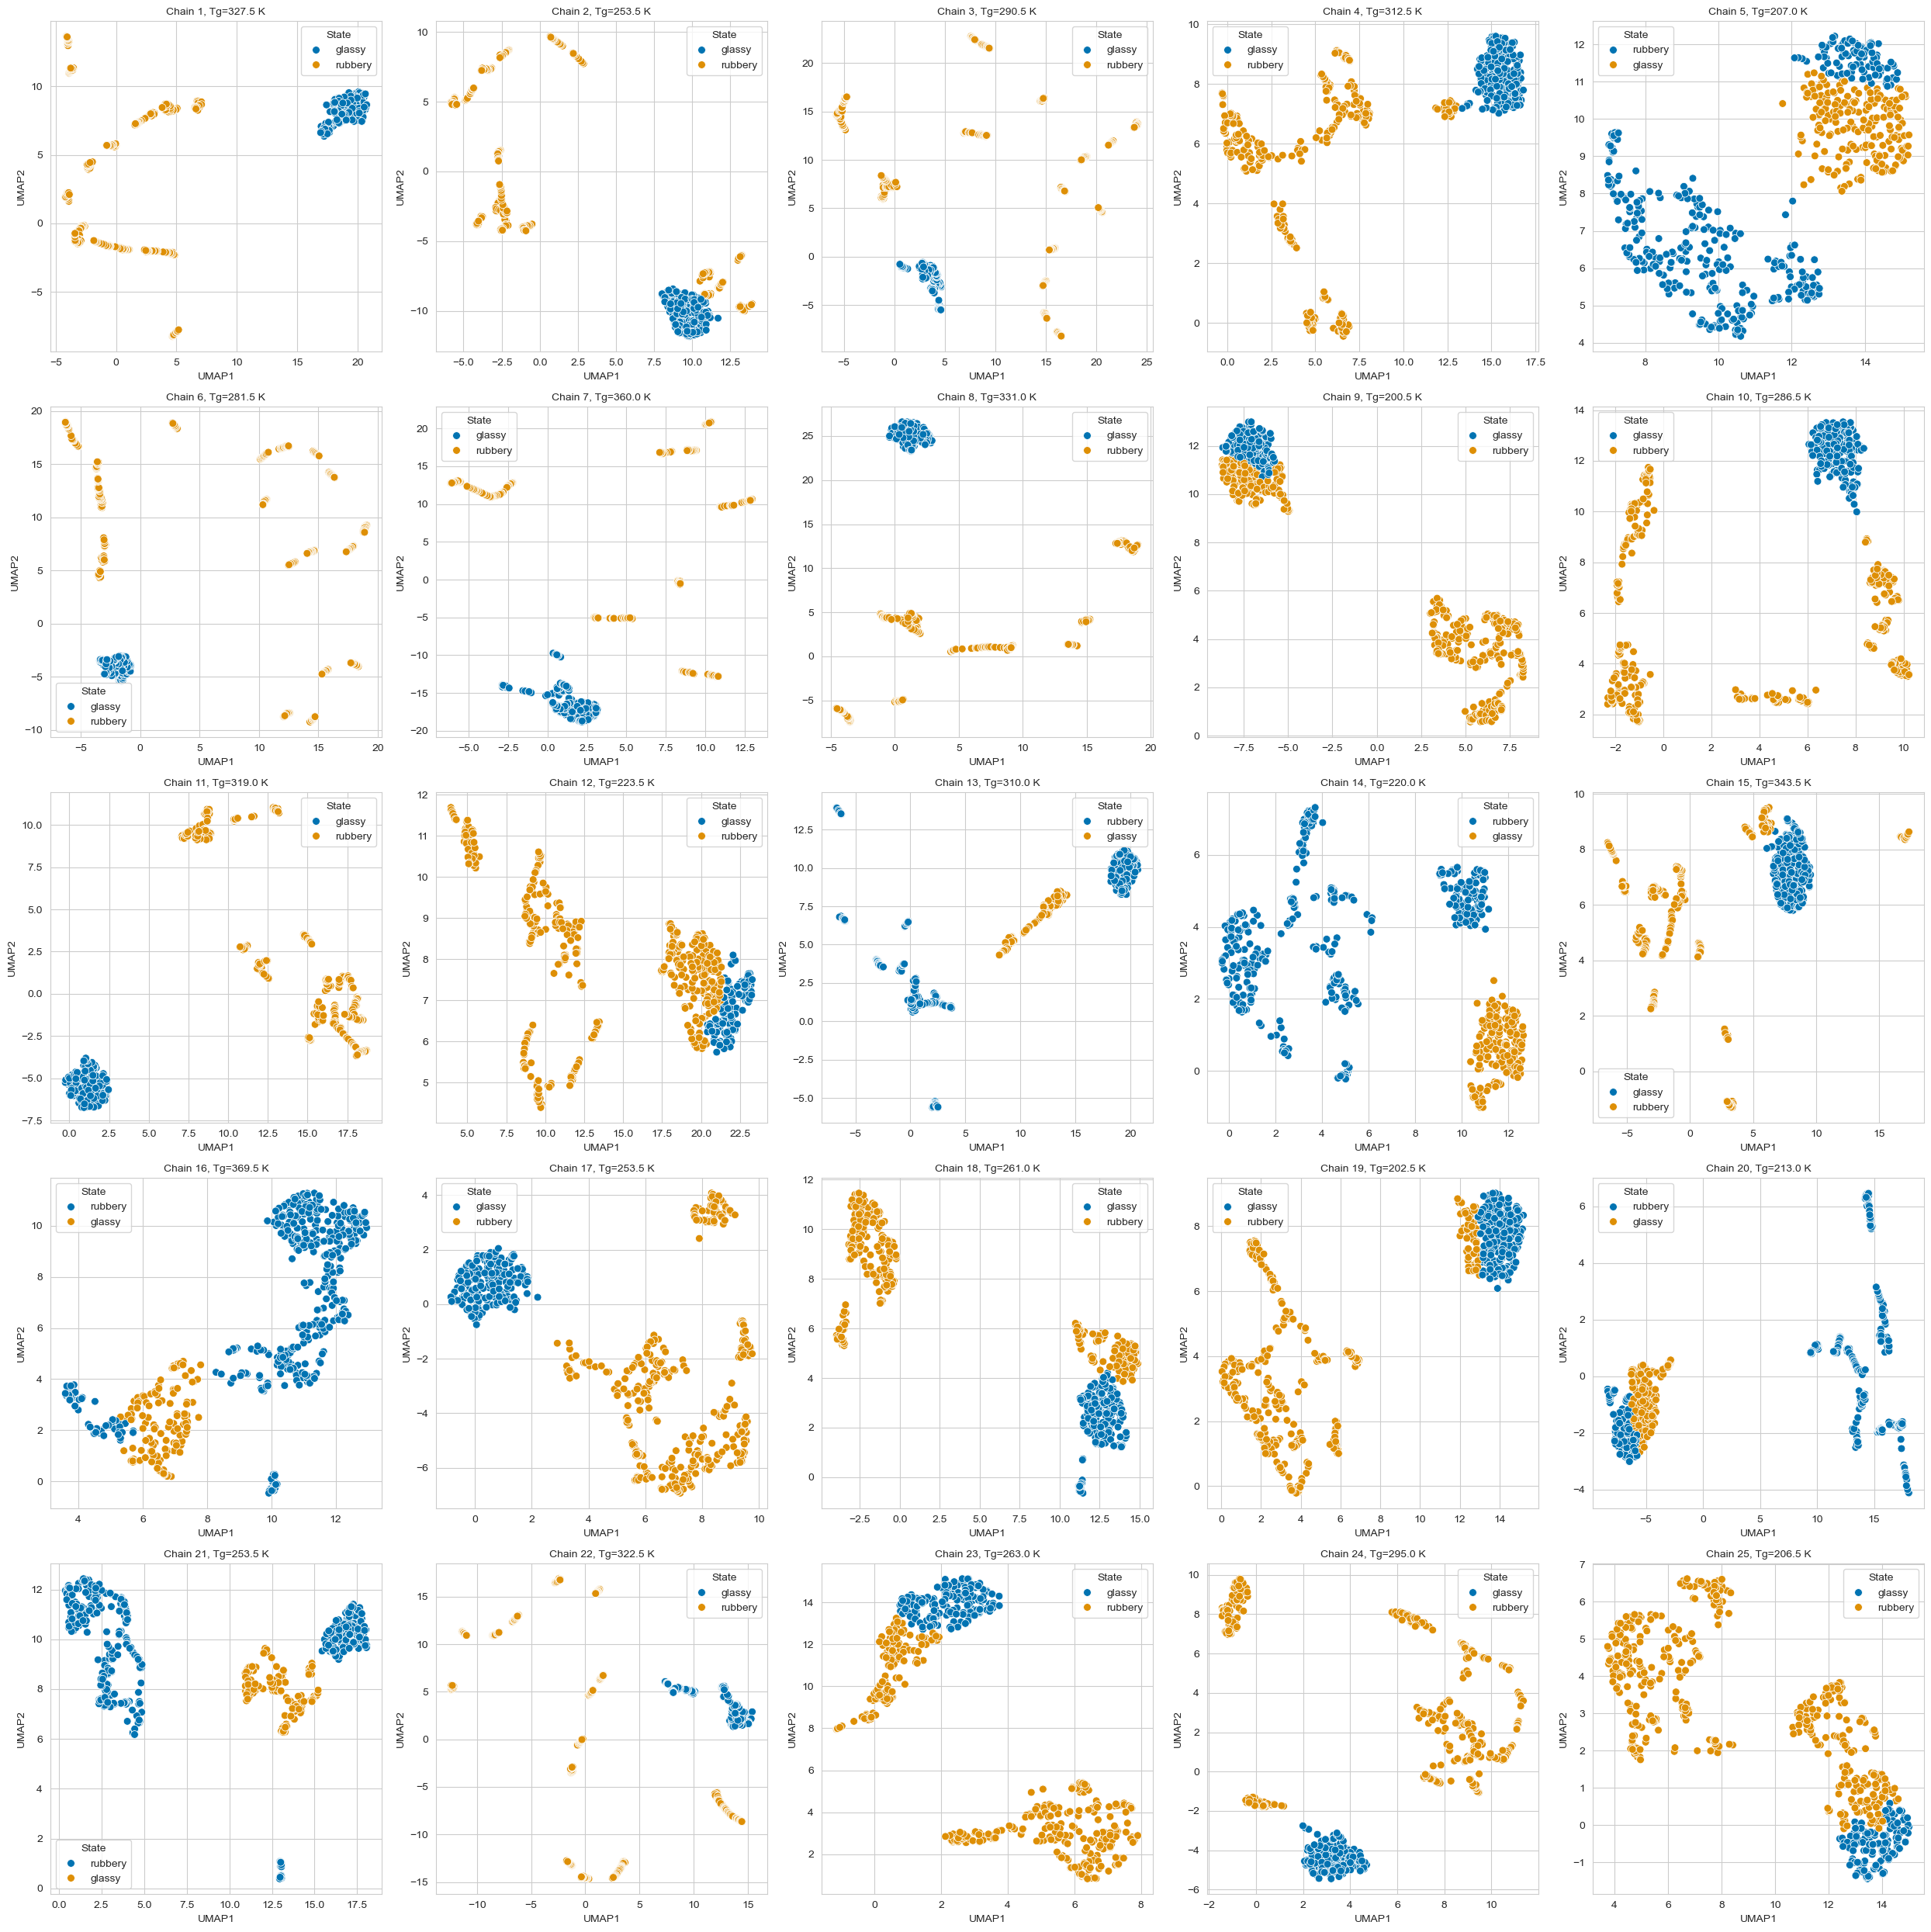

In [27]:
# Plot clustering results over UMAP projection
fig, axes = plt.subplots(5, 5, figsize=(25, 25)) 
axes = axes.flatten()

for idx, i in enumerate(csv_files[:25]): # to eliminate all chains Tg mean values file (for now)
    tg = pd.read_csv('all_chains.csv').iloc[idx]['Tg']
    temp_df = pd.read_csv(i)
    temp_df['temp'] = np.arange(200, 500.5, 0.5)
    temp_df.set_index('temp', inplace=True)
    
    ax = axes[idx]
    sns.scatterplot(data=temp_df, x='UMAP1', y='UMAP2', hue='State', palette='colorblind', s=50, ax=ax)
    ax.set_title(f'Chain {idx+1}, Tg={tg} K', fontsize=10)

for ax in axes[len(csv_files[:25]):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

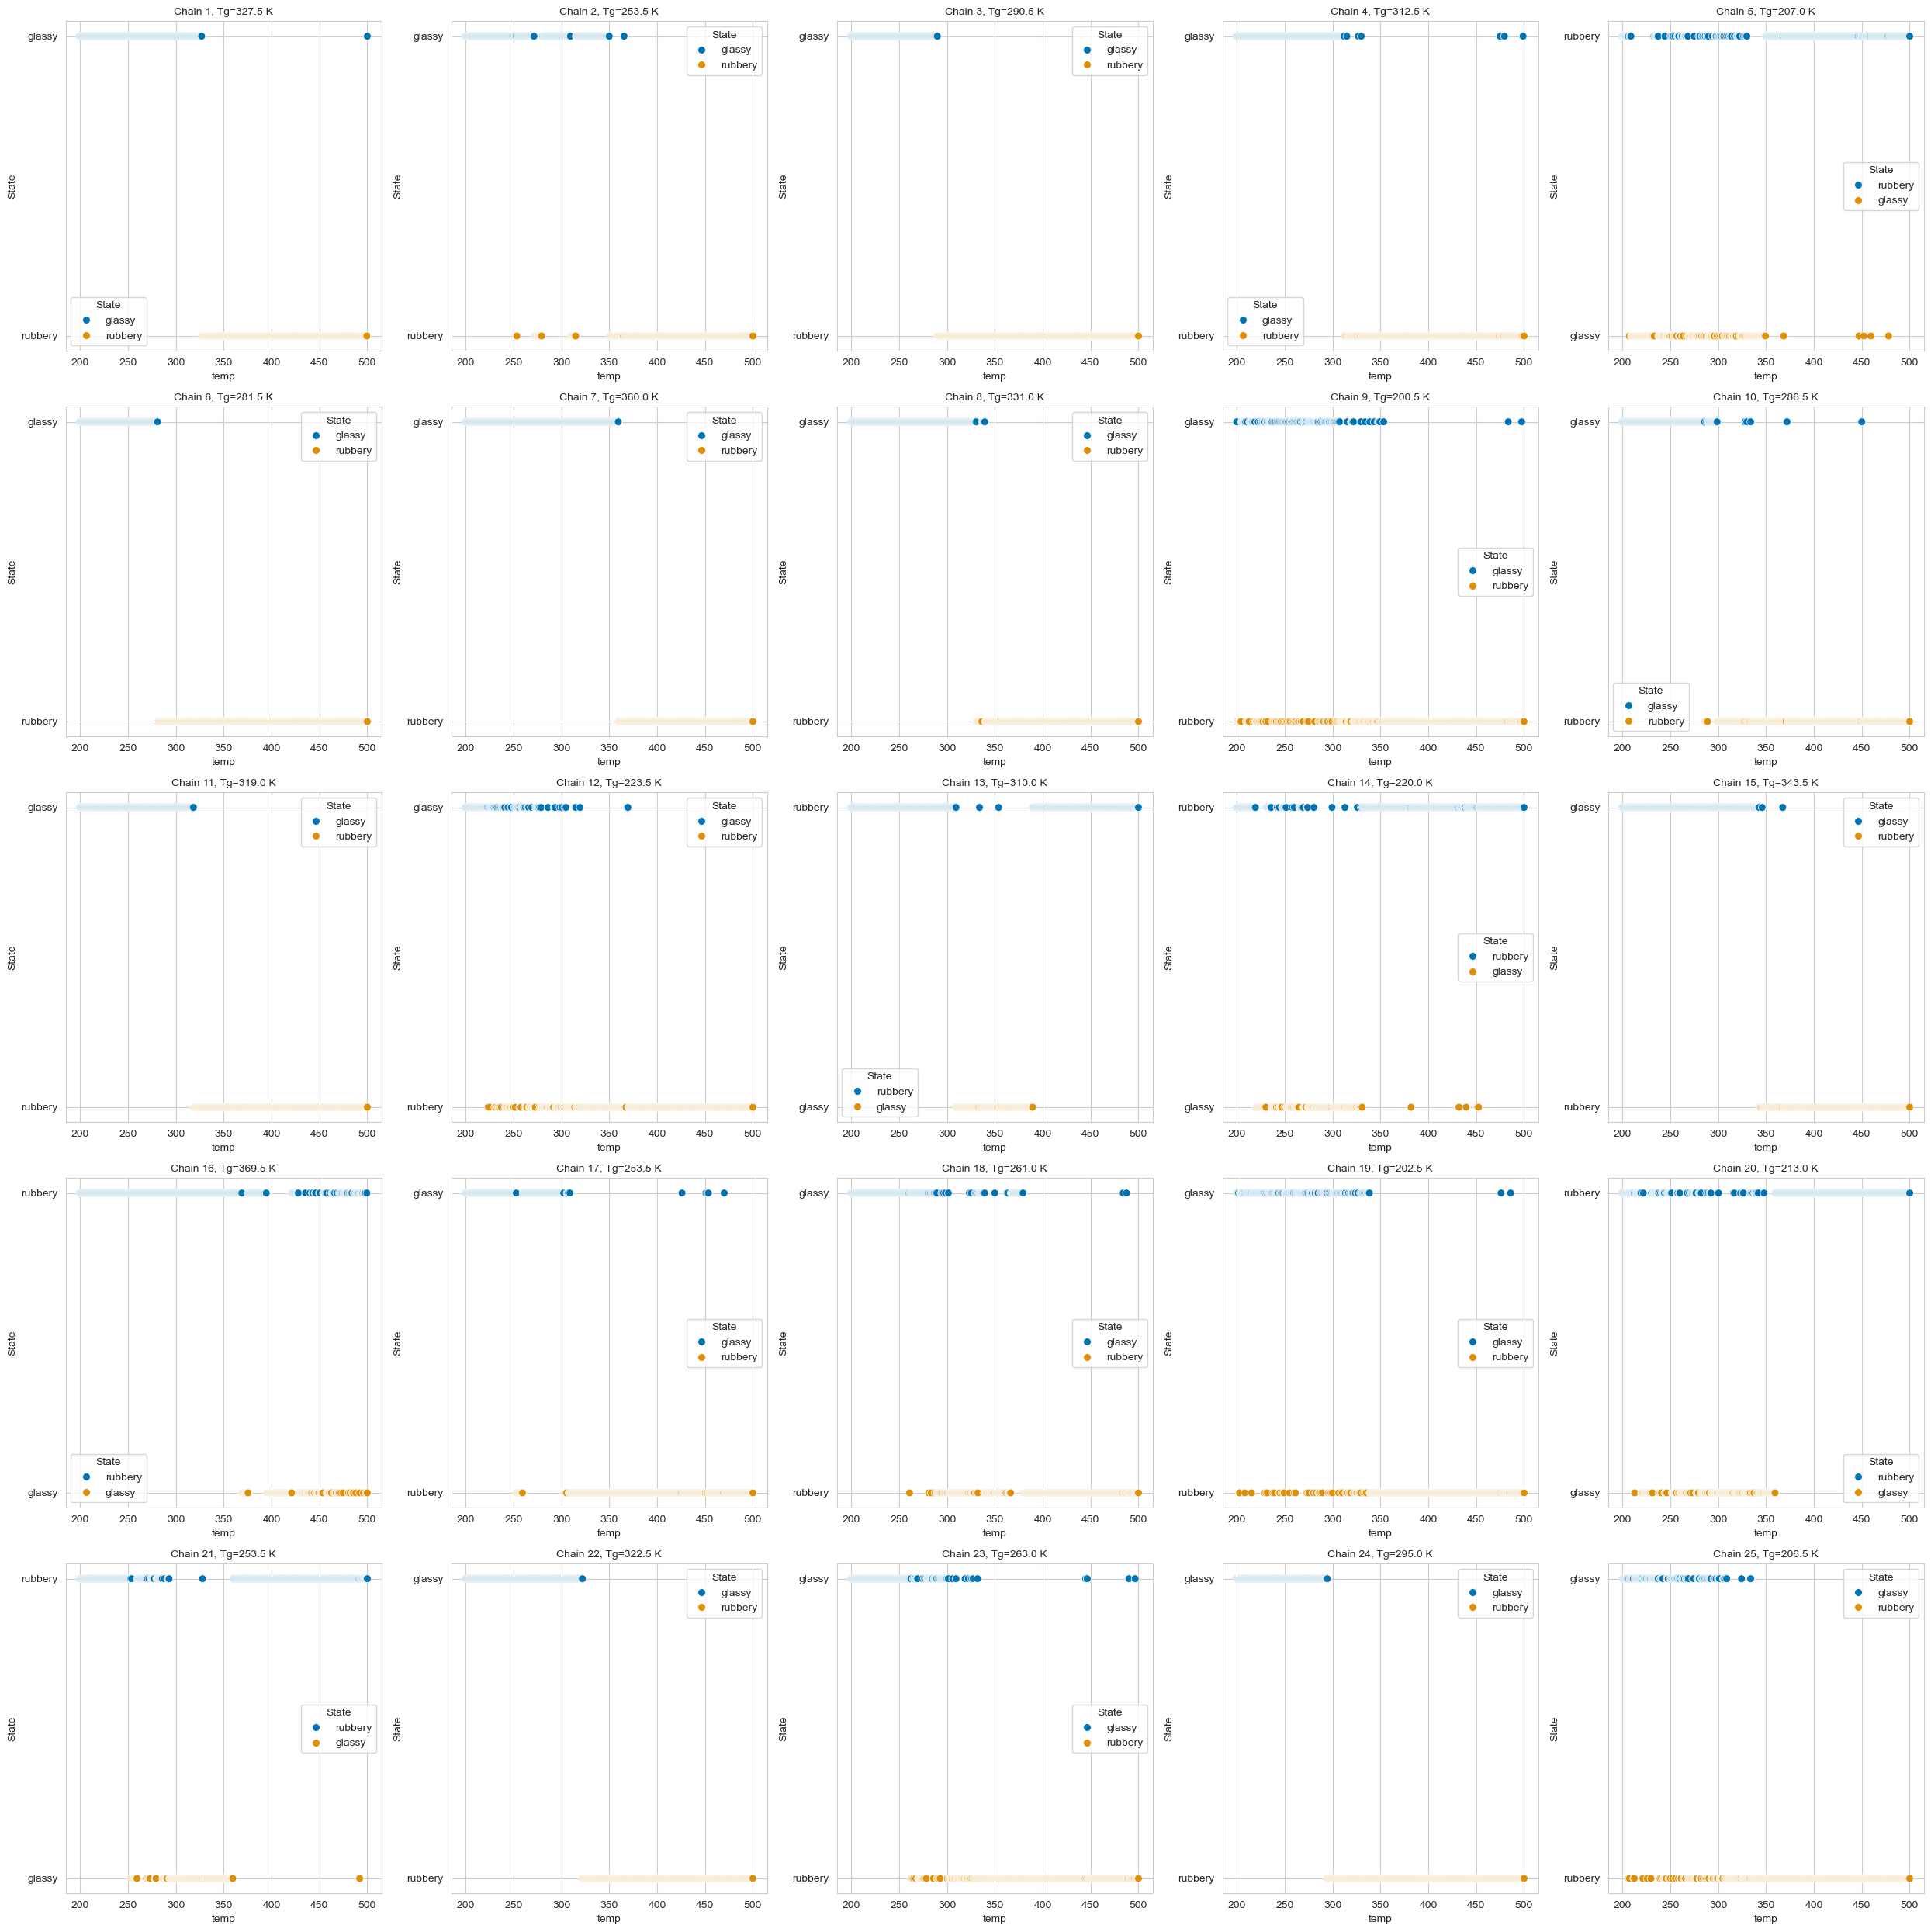

In [28]:
# Plot clustering results vs. temperature
fig, axes = plt.subplots(5, 5, figsize=(25, 25))
axes = axes.flatten()

for idx, i in enumerate(csv_files[:25]):  # to eliminate all chains Tg mean values file (for now)
    tg = pd.read_csv('all_chains.csv').iloc[idx]['Tg']
    temp_df = pd.read_csv(i)
    temp_df['temp'] = np.arange(200, 500.5, 0.5)
    temp_df.set_index('temp', inplace=True)
    
    ax = axes[idx] 
    sns.scatterplot(data=temp_df, x='temp', y='State', hue='State', palette='colorblind', s=50, ax=ax)
    ax.set_title(f'Chain {idx+1}, Tg={tg} K', fontsize=10)  # Add a title to each subplot

# Remove any unused subplots
for ax in axes[len(csv_files[:25]):]:
    ax.axis('off')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

/var/folders/82/29hpsrjj62ndyvrkx204dy600000gn/T/ipykernel_59985/3381959947.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


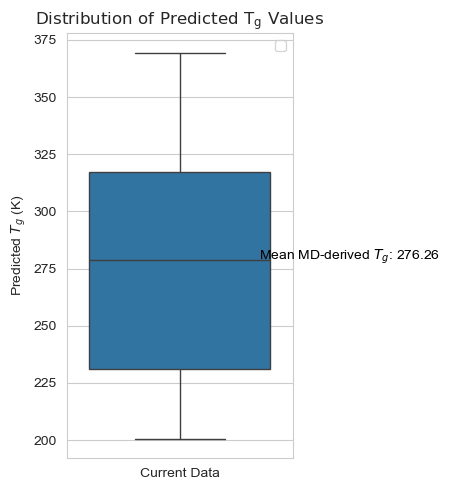

In [29]:
# Plot Tg value spread in melt
# Load the Tg values
tgs_list = pd.read_csv('all_chains.csv')['Tg'].tolist()

# Create a DataFrame for plotting
data = pd.DataFrame({
    'Tg': tgs_list,
    'Group': ['Current Data'] * len(tgs_list)
})

# boxplot
plt.figure(figsize=(5, 5))
sns.boxplot(x='Group', y='Tg', data=data)

# Annotate the mean value
mean_tg = stats.mean(tgs_list)
plt.text(0.75, mean_tg, f"Mean MD-derived $T_g$: {mean_tg:.2f}", 
         color="black", ha="center", va="bottom", fontsize=10)

# Add labels and title
plt.ylabel('Predicted $T_g$ (K)')
plt.xlabel("")
plt.title(r"$\mathrm{Distribution\ of\ Predicted\ T_g\ Values}$")
plt.legend(loc="upper right")
plt.tight_layout()

# Show the plot
plt.show()